#  EDA: Employee Attrition & Retention Risk
### HR Analytics — IBM HR Employee Attrition Dataset



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")

## load the data

In [4]:
df = pd.read_csv(r"../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8")
print(df.shape)

(1470, 35)


## data stats

In [5]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [13]:
df.describe(include="string")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [18]:
print("Number of missing values:")
print(df.isnull().sum().sum())

Number of missing values:
0


In [21]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate EmployeeNumber:", df["EmployeeNumber"].duplicated().sum())

Duplicate rows: 0
Duplicate EmployeeNumber: 0


In [30]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print(f"Constant columns (candidates to drop):{constant_cols}")
for c in constant_cols:
    print(f"{df[c].value_counts()} ({df[c].dtype})")


Constant columns (candidates to drop):['EmployeeCount', 'Over18', 'StandardHours']
EmployeeCount
1    1470
Name: count, dtype: int64 (int64)
Over18
Y    1470
Name: count, dtype: int64 (str)
StandardHours
80    1470
Name: count, dtype: int64 (int64)


##  Target variable — class balance



In [33]:
attrition_counts = df["Attrition"].value_counts()
attrition_rate = df["Attrition"].value_counts(normalize=True).round(2)
print(attrition_counts)
print(attrition_rate)




Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.84
Yes    0.16
Name: proportion, dtype: float64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_26712\2434355653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Attrition", order=["No", "Yes"], palette=["#4C72B0", "#C44E52"])


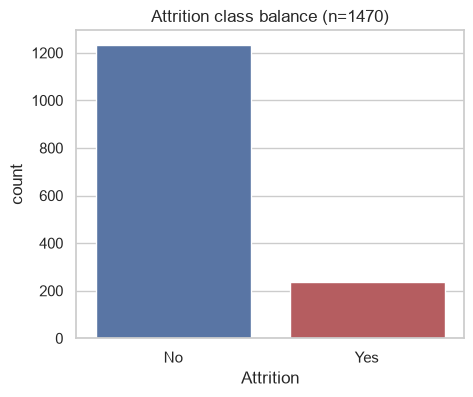

In [35]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Attrition", order=["No", "Yes"], palette=["#4C72B0", "#C44E52"])
plt.title(f"Attrition class balance (n={len(df)})")
plt.show()

##  Attrition rate by department

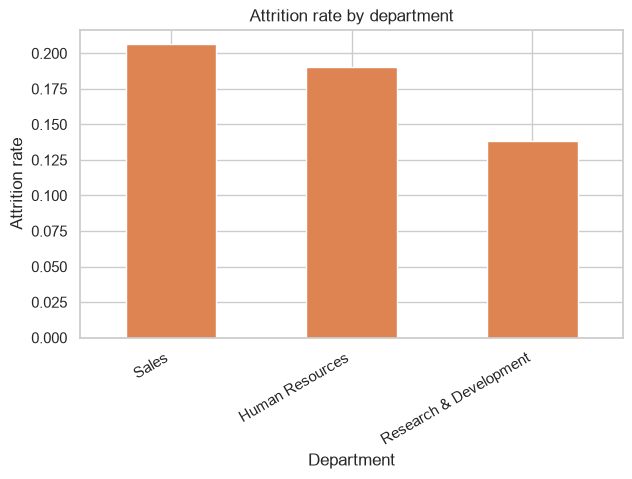

Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition, dtype: float64

In [36]:
dept_attrition = df.groupby("Department")["Attrition"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
dept_attrition.plot(kind="bar", color="#DD8452")
plt.title("Attrition rate by department")
plt.ylabel("Attrition rate")
plt.xticks(rotation=30, ha="right")
plt.show()
dept_attrition


##  Attrition rate by job role

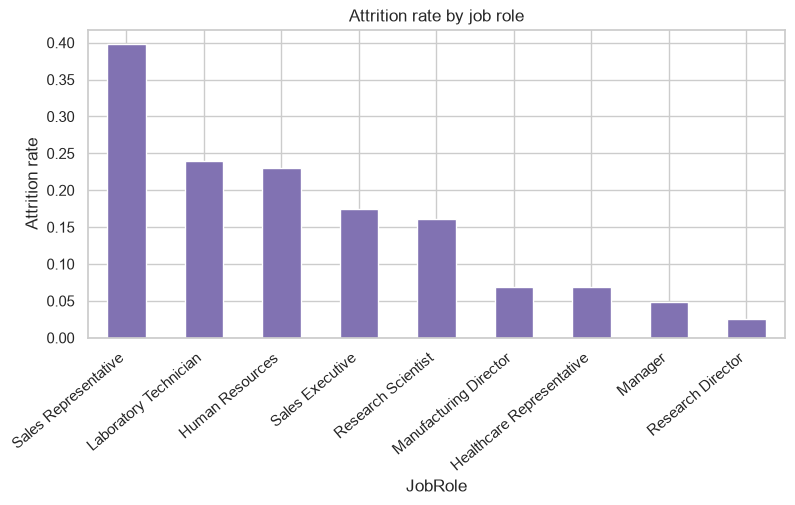

JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition, dtype: float64

In [37]:
role_attrition = df.groupby("JobRole")["Attrition"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
plt.figure(figsize=(9, 4))
role_attrition.plot(kind="bar", color="#8172B2")
plt.title("Attrition rate by job role")
plt.ylabel("Attrition rate")
plt.xticks(rotation=40, ha="right")
plt.show()
role_attrition


## Does OverTime compound with the highest-risk role?

<Figure size 900x500 with 0 Axes>

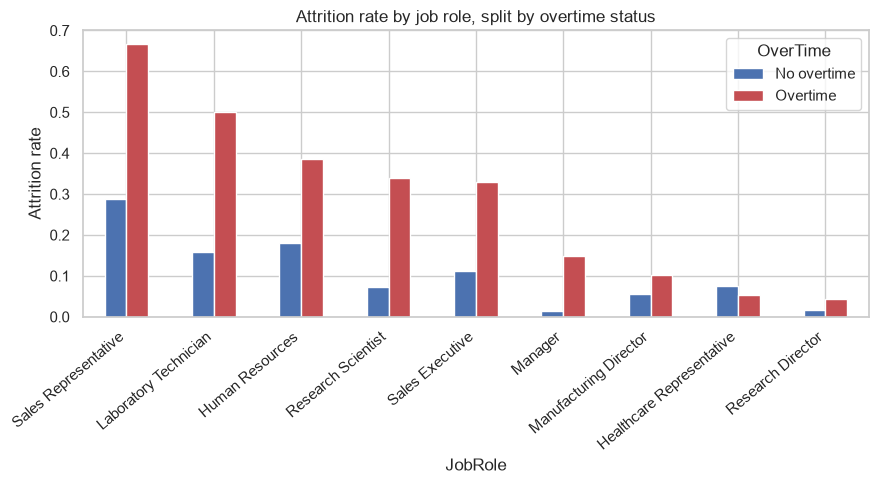

,No overtime,Overtime,gap
JobRole,,,
Sales Representative,0.288136,0.666667,0.378531
Laboratory Technician,0.157360,0.500000,0.342640
Human Resources,0.179487,0.384615,0.205128
Research Scientist,0.071795,0.340206,0.268411
Sales Executive,0.112069,0.329787,0.217718
Manager,0.013333,0.148148,0.134815
Manufacturing Director,0.056604,0.102564,0.045960
Healthcare Representative,0.074468,0.054054,-0.020414
Research Director,0.017544,0.043478,0.025934


In [50]:
interaction = (
    df.groupby(["JobRole", "OverTime"])["Attrition"]
    .apply(lambda s: (s == "Yes").mean())
    .unstack()
    .sort_values("Yes", ascending=False)
)
interaction.columns = ["No overtime", "Overtime"]
interaction["gap"] = interaction["Overtime"] - interaction["No overtime"]

plt.figure(figsize=(9, 5))
interaction[["No overtime", "Overtime"]].plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#C44E52"])
plt.title("Attrition rate by job role, split by overtime status")
plt.ylabel("Attrition rate")
plt.xticks(rotation=40, ha="right")
plt.legend(title="OverTime")
plt.tight_layout()
plt.show()

interaction

##  Attrition rate by overtime

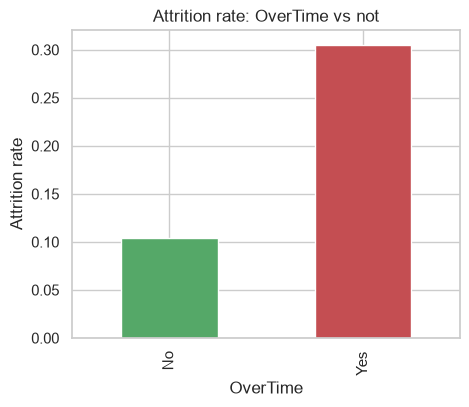

OverTime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64

In [38]:
overtime_attrition = df.groupby("OverTime")["Attrition"].apply(lambda s: (s == "Yes").mean())
overtime_attrition.plot(kind="bar", figsize=(5, 4), color=["#55A868", "#C44E52"])
plt.title("Attrition rate: OverTime vs not")
plt.ylabel("Attrition rate")
plt.show()
overtime_attrition


## Ranking all numeric features by their raw association with attrition

In [48]:
target = (df["Attrition"] == "Yes").astype(int)
numeric_candidates = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_candidates = [c for c in numeric_candidates if c not in constant_cols]

signal_ranking = (
    pd.Series({col: df[col].corr(target) for col in numeric_candidates})
    .sort_values(key=abs, ascending=False)
)
print("Numeric features ranked by correlation with Attrition:")
signal_ranking

Numeric features ranked by correlation with Attrition:


TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
DistanceFromHome            0.077924
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
NumCompaniesWorked          0.043494
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
MonthlyRate                 0.015170
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
dtype: float64

## Income & Distance from home vs attrition



C:\Users\lenovo\AppData\Local\Temp\ipykernel_26712\2524100176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["No", "Yes"], ax=axes[0], palette=["#4C72B0", "#C44E52"])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26712\2524100176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="DistanceFromHome", order=["No", "Yes"], ax=axes[1], palette=["#4C72B0", "#C44E52"])


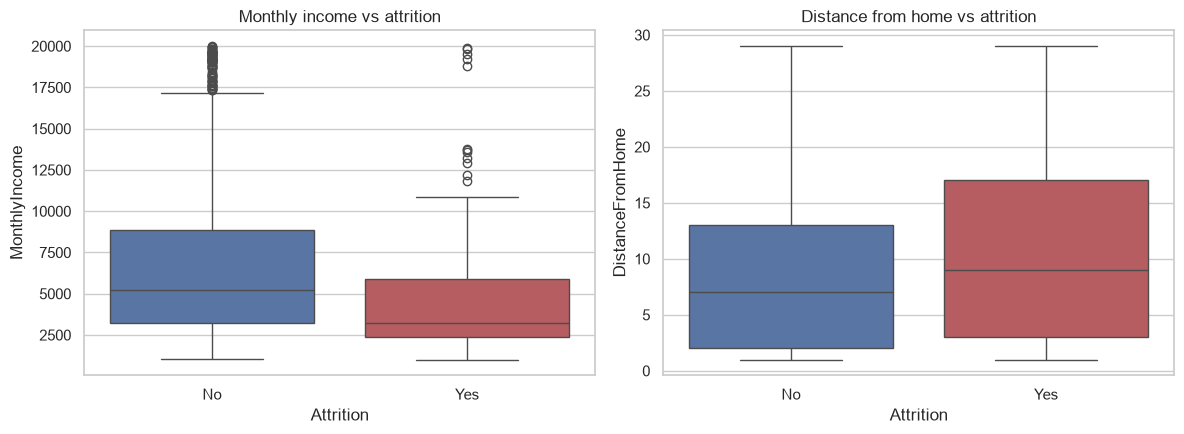

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["No", "Yes"], ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Monthly income vs attrition")

sns.boxplot(data=df, x="Attrition", y="DistanceFromHome", order=["No", "Yes"], ax=axes[1], palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Distance from home vs attrition")
plt.tight_layout()
plt.show()


## satisfaction & work-life balance vs attrition

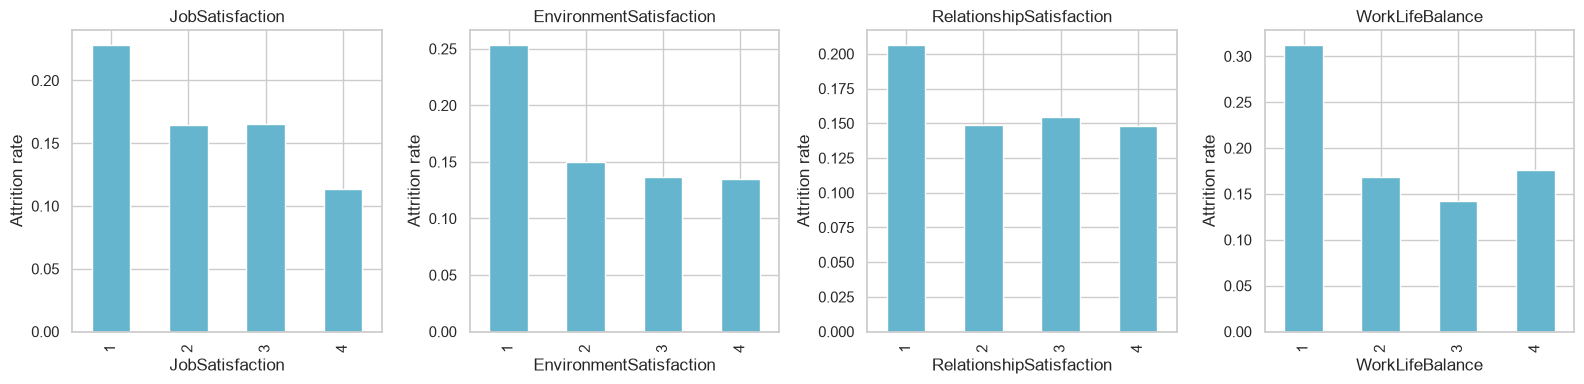

In [40]:
satisfaction_cols = ["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]
fig, axes = plt.subplots(1, len(satisfaction_cols), figsize=(16, 4))
for ax, col in zip(axes, satisfaction_cols):
    rate_by_level = df.groupby(col)["Attrition"].apply(lambda s: (s == "Yes").mean())
    rate_by_level.plot(kind="bar", ax=ax, color="#64B5CD")
    ax.set_title(col)
    ax.set_ylabel("Attrition rate")
plt.tight_layout()
plt.show()


##  Tenure fields 




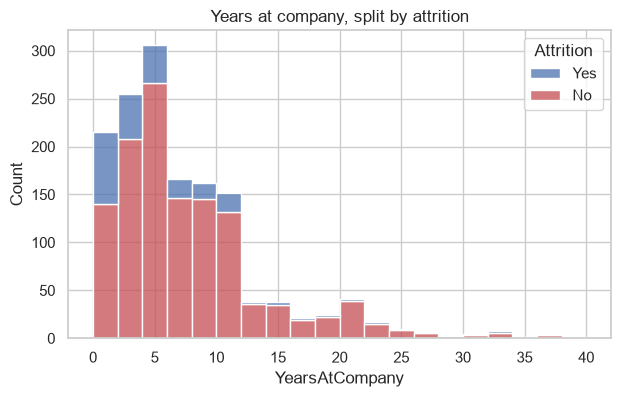

In [42]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="YearsAtCompany", hue="Attrition", multiple="stack", bins=20, palette=["#4C72B0", "#C44E52"])
plt.title("Years at company, split by attrition")
plt.show()


In [43]:
print(df.groupby("Attrition")["YearsAtCompany"].describe())

            count      mean       std  min  25%  50%   75%   max
Attrition                                                       
No         1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
Yes         237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0


In [44]:
tenure_cols = ["YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager", "TotalWorkingYears"]
df[tenure_cols].describe()


,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,7.008163,4.229252,2.187755,4.123129,11.279592
std,6.126525,3.623137,3.222430,3.568136,7.780782
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,0.000000,2.000000,6.000000
50%,5.000000,3.000000,1.000000,3.000000,10.000000
75%,9.000000,7.000000,3.000000,7.000000,15.000000
max,40.000000,18.000000,15.000000,17.000000,40.000000


## Correlation among numeric features

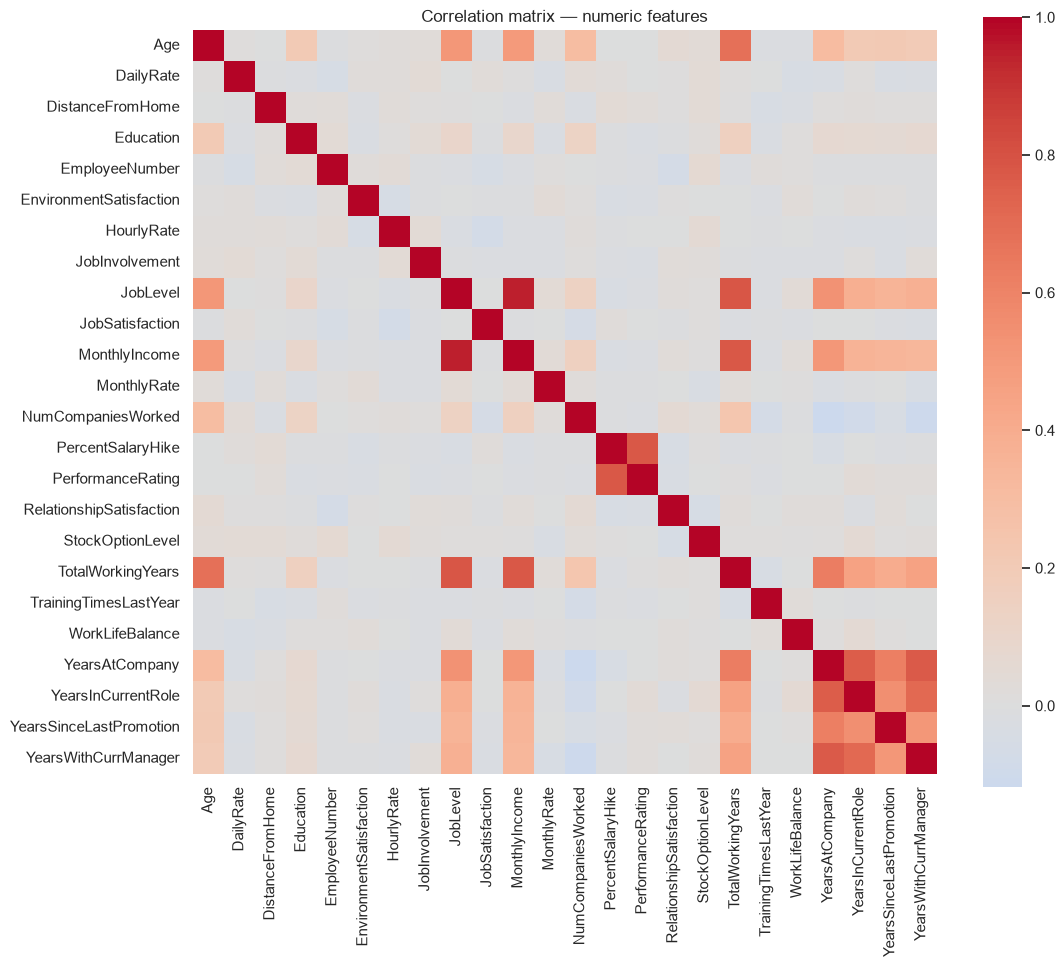

In [45]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in constant_cols]

corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation matrix — numeric features")
plt.show()


## Check Multicollinearity

In [46]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr = corr_pairs[corr_pairs.abs() > 0.7]
print("Highly correlated numeric pairs (|r| > 0.7):")
print(high_corr)


Highly correlated numeric pairs (|r| > 0.7):
JobLevel            MonthlyIncome           0.950300
                    TotalWorkingYears       0.782208
PercentSalaryHike   PerformanceRating       0.773550
MonthlyIncome       TotalWorkingYears       0.772893
YearsAtCompany      YearsWithCurrManager    0.769212
                    YearsInCurrentRole      0.758754
YearsInCurrentRole  YearsWithCurrManager    0.714365
dtype: float64


## Summary of EDA findings

**Class balance:** 84% No / 16% Yes. Imbalanced — will use PR-AUC and
class weighting in Phase 3, not plain accuracy.

**Columns to drop:** `EmployeeCount`, `Over18`, `StandardHours` — all
constant, zero signal.

**Department & role:** Sales has the highest attrition rate (20.6%),
ahead of HR (19.0%) and R&D (13.8%). Sales Representative is the highest-risk
role at 39.8% — more than double any other role.

**OverTime:** Big effect — 30.5% attrition with overtime vs 10.4% without.

**OverTime × Role interaction:** These compound. Sales Reps working overtime
hit 66.7% attrition, far above either factor alone. This is the strongest
single finding in the EDA.

**Income & satisfaction:** Lower income and lower satisfaction scores both
associate with higher attrition, in the expected direction.

**Numeric feature ranking:** `TotalWorkingYears`, `JobLevel`, and
`YearsInCurrentRole` show the strongest correlation with attrition among
numeric features — all negative (more experience/seniority = less attrition).

**Tenure:** Leavers have a shorter median tenure (3 yrs vs 6 yrs) —
attrition is concentrated early in someone's time at the company.

**Multicollinearity:** `JobLevel` and `MonthlyIncome` are almost redundant
(r = 0.95). Watch this if using logistic regression in Phase 3.

**Next steps for Phase 2:** drop the 3 dead columns, prioritize `OverTime`
and `JobRole` (and their interaction) as features, build a tenure-ratio
feature, stratify the train/test split on `Attrition`.